In [1]:
# ==============================================================================
# Chandeleur Islands — 4-box sediment budget model
# csherwood@usgs.gov, 2026-06-18, generated with Claude Sonnet 4.6
#
# State variables  V_i(t)  [m³/m²]  volumetric inventory per plan area
# Fluxes           q_*     [m³/m²/yr]
#
# Boxes
#   IN = island_north     (15 km along × 1 km cross)
#   IS = island_south     (15 km along × 1 km cross)
#   ON = offshore_north   (15 km along × 3 km cross)
#   OS = offshore_south   (15 km along × 3 km cross)
#
# Flux sign convention: positive = into the box
#
# Cross-shore fluxes (island ↔ offshore)
#   q_out_j   outwash   island_j → offshore_j   (negative for island_j)
#   q_on_j    onshore   offshore_j → island_j   (positive for island_j)
#   q_mb_j    moving-boundary (shoreline retreat) — KINEMATIC, not a free param
#             q_mb_j = -dx_j * h_j / W_isl  (island; h_j = local sand thickness)
#             equal-and-opposite term enters offshore_j scaled by W_off
#
# Alongshore fluxes (offshore column only; island-island flux = 0)
#   q_in      into offshore_south from south boundary
#   q_LS      offshore_south → offshore_north
#   q_out_N   out of offshore_north at north boundary
#
# Subsidence
#   q_sub     apparent volume loss, same for all boxes  (positive magnitude)
#
# Governing equations
#   dV_IN/dt = q_on_N  - q_out_N + q_mb_isl_N - q_sub
#   dV_IS/dt = q_on_S  - q_out_S + q_mb_isl_S - q_sub
#   dV_ON/dt = q_out_N - q_on_N  - q_mb_off_N + q_LS - q_out_N_LS - q_sub
#   dV_OS/dt = q_out_S - q_on_S  - q_mb_off_S + q_in - q_LS       - q_sub
#
# Transgression flux (diagnostic, positive = onshore / progradational)
#   q_trans_j = q_on_j - q_out_j + q_mb_isl_j
#
# References
#   Stockdon et al. (2006) Coast. Eng. 53:573-588  (runup; used elsewhere)
#   Cowell et al. (2003) J. Coast. Res. 19:812-827  (shoreface translation model)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Geometry ──────────────────────────────────────────────────────────────────
L     = 15_000.0   # m  alongshore length (both north and south halves)
W_isl = 1_000.0    # m  island cross-shore width
W_off = 3_000.0    # m  offshore cross-shore width

A_isl = L * W_isl  # m²
A_off = L * W_off  # m²

BOXES = ['IN', 'IS', 'ON', 'OS']
LABELS = {
    'IN': 'island_north',
    'IS': 'island_south',
    'ON': 'offshore_north',
    'OS': 'offshore_south',
}

# ── Time span ─────────────────────────────────────────────────────────────────
YEAR_START = 1988
YEAR_END   = 2024
YEARS      = np.arange(YEAR_START, YEAR_END + 1)
N_YEARS    = len(YEARS)           # 37 years
DT         = 1.0                  # yr (annual time step)

print(f'Boxes: {BOXES}')
print(f'Island area: {A_isl/1e6:.1f} km²   Offshore area: {A_off/1e6:.1f} km²')
print(f'Time span: {YEAR_START}–{YEAR_END}  ({N_YEARS} years)')

Boxes: ['IN', 'IS', 'ON', 'OS']
Island area: 15.0 km²   Offshore area: 45.0 km²
Time span: 1988–2024  (37 years)


In [2]:
# ==============================================================================
# CELL 2 — Inputs: initial/final volumes and known forcing
#
# Replace the placeholder values below with measured quantities:
#   V_init_*  initial volume  [m³/m²]  (year YEAR_START)
#   V_final_* final   volume  [m³/m²]  (year YEAR_END)
#   dx_j      annual mean shoreline change rate [m/yr]
#             positive = landward retreat; shape (N_YEARS-1,) or scalar
#   h_j       sand thickness at island–offshore boundary [m]
#             used for moving-boundary flux; scalar or shape (N_YEARS-1,)
#
# All fluxes below are INITIAL GUESSES / placeholders.
# Cell 3 will solve for the unknown cross-shore fluxes that close the budget.
# ==============================================================================

# ── Initial and final volumetric inventories [m³/m²] ─────────────────────────
# Placeholder: 1 m everywhere.  Replace with survey-derived values.
V_init = {'IN': 1.0, 'IS': 1.0, 'ON': 1.0, 'OS': 1.0}
V_final= {'IN': 1.0, 'IS': 1.0, 'ON': 1.0, 'OS': 1.0}

# ── Shoreline change rates [m/yr] (positive = landward retreat) ──────────────
# Scalar → applied uniformly every year.  Replace with annual DSAS output.
dx_N = 5.0   # m/yr   island_north shoreline change  (retreat positive)
dx_S = 5.0   # m/yr   island_south shoreline change

# ── Sand thickness at the island–offshore boundary [m] ───────────────────────
# Used to convert shoreline change to volume flux.
# Can be set to the island box mean thickness V/W_isl (updated each step)
# or to a fixed observed value.
h_N  = None   # m  None → use dynamic estimate V_IN(t)/W_isl
h_S  = None   # m  None → use dynamic estimate V_IS(t)/W_isl

# ── Subsidence rate [m/yr] (positive magnitude, applied as loss) ─────────────
q_sub = 0.01   # m³/m²/yr

# ── Alongshore fluxes [m³/m²/yr] (initially zero) ───────────────────────────
# These are all referenced to the offshore plan area.
q_in      = 0.0   # into offshore_south from south boundary
q_LS      = 0.0   # offshore_south → offshore_north
q_out_N_LS= 0.0   # out of offshore_north at north boundary

# ── Cross-shore fluxes — INITIAL GUESSES [m³/m²/yr] ─────────────────────────
# (referenced to island plan area for island boxes, offshore for offshore boxes)
# Cell 3 will solve for the combination consistent with the observed ΔV.
q_out_N = 0.02   # outwash island_north → offshore_north
q_on_N  = 0.01   # onshore offshore_north → island_north
q_out_S = 0.02
q_on_S  = 0.01

print('Inputs loaded.')
print(f'  V_init : {V_init}')
print(f'  V_final: {V_final}')
print(f'  dV_obs : ', {k: round(V_final[k]-V_init[k],4) for k in BOXES})
print(f'  dx_N={dx_N} m/yr   dx_S={dx_S} m/yr   q_sub={q_sub} m³/m²/yr')

Inputs loaded.
  V_init : {'IN': 1.0, 'IS': 1.0, 'ON': 1.0, 'OS': 1.0}
  V_final: {'IN': 1.0, 'IS': 1.0, 'ON': 1.0, 'OS': 1.0}
  dV_obs :  {'IN': 0.0, 'IS': 0.0, 'ON': 0.0, 'OS': 0.0}
  dx_N=5.0 m/yr   dx_S=5.0 m/yr   q_sub=0.01 m³/m²/yr


In [3]:
# ==============================================================================
# CELL 3 — Moving-boundary flux
#
# q_mb is kinematic: it is DETERMINED by the shoreline change rate and
# sand thickness, not an independently tunable parameter.
#
# For island box j:
#   q_mb_isl_j = -(dx_j * h_j) / W_isl      [m³/m²/yr, negative = loss]
#
# The equal-and-opposite volume enters the offshore box, scaled by the
# ratio of areas so that the absolute volume flux is conserved:
#   q_mb_off_j = +(dx_j * h_j) / W_off       [m³/m²/yr, positive = gain]
#
# h_j may be supplied as a constant or estimated dynamically from V_j(t)/W_isl.
# ==============================================================================

def moving_boundary_flux(dx, V_isl, h_fixed=None):
    """
    Parameters
    ----------
    dx      : float, m/yr (positive = landward retreat)
    V_isl   : float, current island volume [m³/m²]
    h_fixed : float or None; if None, use V_isl/W_isl

    Returns
    -------
    q_isl : float, flux into island box    [m³/m²/yr]  (negative for retreat)
    q_off : float, flux into offshore box  [m³/m²/yr]  (positive for retreat)
    """
    h = h_fixed if h_fixed is not None else max(V_isl, 0.0) / W_isl
    q_isl = -(dx * h) / W_isl
    q_off = +(dx * h) / W_off
    return q_isl, q_off

# Quick diagnostic at initial conditions
qmb_isl_N, qmb_off_N = moving_boundary_flux(dx_N, V_init['IN'], h_N)
qmb_isl_S, qmb_off_S = moving_boundary_flux(dx_S, V_init['IS'], h_S)
print('Moving-boundary fluxes at t=0:')
print(f'  North: island {qmb_isl_N:+.5f}  offshore {qmb_off_N:+.5f}  m³/m²/yr')
print(f'  South: island {qmb_isl_S:+.5f}  offshore {qmb_off_S:+.5f}  m³/m²/yr')
# Volume conservation check: absolute volume must balance
abs_isl = abs(qmb_isl_N) * A_isl
abs_off = qmb_off_N * A_off
print(f'  Conservation check North: |isl flux|×A_isl = {abs_isl:.1f}  '
      f'off flux×A_off = {abs_off:.1f} m³/yr  (should match)')

Moving-boundary fluxes at t=0:
  North: island -0.00001  offshore +0.00000  m³/m²/yr
  South: island -0.00001  offshore +0.00000  m³/m²/yr
  Conservation check North: |isl flux|×A_isl = 75.0  off flux×A_off = 75.0 m³/yr  (should match)


In [4]:
# ==============================================================================
# CELL 4 — Forward model
#
# Given all fluxes (cross-shore, moving-boundary, subsidence, alongshore),
# integrate the four ODEs forward in time using Euler steps (DT = 1 yr).
#
# Outputs:
#   V_ts    : DataFrame (N_YEARS × 4) of volumetric inventories
#   flux_ts : DataFrame (N_YEARS-1 × n_fluxes) of annual fluxes
#
# Call run_forward() to test a particular flux set.
# Cell 5 will use this function inside an optimiser to close the budget.
# ==============================================================================

def run_forward(V0, fluxes, years=YEARS, dt=DT):
    """
    Parameters
    ----------
    V0     : dict  {'IN','IS','ON','OS'} initial volumes [m³/m²]
    fluxes : dict  flux parameters (see body below)
    years  : array of year integers

    Returns
    -------
    V_ts    : DataFrame, index=years, columns=BOXES
    flux_ts : DataFrame, index=years[:-1], columns=flux names
    """
    n = len(years)
    V  = {b: np.zeros(n) for b in BOXES}
    FL = {k: np.zeros(n-1) for k in
          ['q_out_N','q_on_N','q_mb_isl_N','q_mb_off_N',
           'q_out_S','q_on_S','q_mb_isl_S','q_mb_off_S',
           'q_sub',
           'q_in','q_LS','q_out_N_LS',
           'q_trans_N','q_trans_S']}

    for b in BOXES:
        V[b][0] = V0[b]

    for t in range(n - 1):
        # Moving-boundary (kinematic)
        _dx_N = np.atleast_1d(fluxes['dx_N'])[t] if np.ndim(fluxes['dx_N']) > 0 else fluxes['dx_N']
        _dx_S = np.atleast_1d(fluxes['dx_S'])[t] if np.ndim(fluxes['dx_S']) > 0 else fluxes['dx_S']
        mb_isl_N, mb_off_N = moving_boundary_flux(_dx_N, V['IN'][t], fluxes.get('h_N'))
        mb_isl_S, mb_off_S = moving_boundary_flux(_dx_S, V['IS'][t], fluxes.get('h_S'))

        # Cross-shore
        qon_N  = fluxes['q_on_N']
        qon_S  = fluxes['q_on_S']
        qout_N = fluxes['q_out_N']
        qout_S = fluxes['q_out_S']

        # Subsidence
        sub    = fluxes['q_sub']

        # Alongshore
        q_in_  = fluxes.get('q_in', 0.0)
        q_LS_  = fluxes.get('q_LS', 0.0)
        q_oN_  = fluxes.get('q_out_N_LS', 0.0)

        # dV/dt
        dV_IN = qon_N  - qout_N + mb_isl_N - sub
        dV_IS = qon_S  - qout_S + mb_isl_S - sub
        dV_ON = qout_N - qon_N  + mb_off_N + q_LS_ - q_oN_ - sub
        dV_OS = qout_S - qon_S  + mb_off_S + q_in_ - q_LS_ - sub

        V['IN'][t+1] = V['IN'][t] + dV_IN * dt
        V['IS'][t+1] = V['IS'][t] + dV_IS * dt
        V['ON'][t+1] = V['ON'][t] + dV_ON * dt
        V['OS'][t+1] = V['OS'][t] + dV_OS * dt

        # Record fluxes
        FL['q_out_N'][t]    = qout_N
        FL['q_on_N'][t]     = qon_N
        FL['q_mb_isl_N'][t] = mb_isl_N
        FL['q_mb_off_N'][t] = mb_off_N
        FL['q_out_S'][t]    = qout_S
        FL['q_on_S'][t]     = qon_S
        FL['q_mb_isl_S'][t] = mb_isl_S
        FL['q_mb_off_S'][t] = mb_off_S
        FL['q_sub'][t]      = sub
        FL['q_in'][t]       = q_in_
        FL['q_LS'][t]       = q_LS_
        FL['q_out_N_LS'][t] = q_oN_
        FL['q_trans_N'][t]  = qon_N  - qout_N + mb_isl_N
        FL['q_trans_S'][t]  = qon_S  - qout_S + mb_isl_S

    V_ts    = pd.DataFrame(V,     index=years)
    flux_ts = pd.DataFrame(FL,    index=years[:-1])
    V_ts.index.name    = 'year'
    flux_ts.index.name = 'year'
    return V_ts, flux_ts

# ── Test run with placeholder fluxes ─────────────────────────────────────────
flux_params = dict(
    q_out_N=q_out_N, q_on_N=q_on_N,
    q_out_S=q_out_S, q_on_S=q_on_S,
    q_sub=q_sub,
    dx_N=dx_N, dx_S=dx_S, h_N=h_N, h_S=h_S,
    q_in=q_in, q_LS=q_LS, q_out_N_LS=q_out_N_LS,
)
V_ts, flux_ts = run_forward(V_init, flux_params)

print('Forward model: final volumes (placeholder fluxes):')
print(V_ts.iloc[-1].round(4))
print('\nObserved final volumes:')
print(pd.Series(V_final).round(4))
print('\nResiduals (modelled − observed):')
print((V_ts.iloc[-1] - pd.Series(V_final)).round(4))

Forward model: final volumes (placeholder fluxes):
IN    0.2799
IS    0.2799
ON    1.0000
OS    1.0000
Name: 2024, dtype: float64

Observed final volumes:
IN    1.0
IS    1.0
ON    1.0
OS    1.0
dtype: float64

Residuals (modelled − observed):
IN   -0.7201
IS   -0.7201
ON    0.0000
OS    0.0000
dtype: float64


In [5]:
# ==============================================================================
# CELL 5 — Solve for cross-shore fluxes that close the budget
#
# Given:
#   V_init  (4 values, specified)
#   V_final (4 values, specified)
#   q_sub   (specified)
#   q_mb_*  (kinematic, derived from dx and h)
#   q_in, q_LS, q_out_N_LS  (specified, initially 0)
#
# Unknowns (4): q_out_N, q_on_N, q_out_S, q_on_S
# Constraints (4, one per box):  V_final_i = V_init_i + sum(fluxes)*T
#
# For constant fluxes this is a linear system. We use scipy.optimize.least_squares
# so it generalises easily to time-varying or nonlinear cases.
#
# Constraint: q_out_N, q_out_S >= 0  (outwash only goes seaward)
#             q_on_N,  q_on_S  >= 0  (onshore flux only goes landward)
#
# If you have ADDITIONAL constraints (e.g. measured q_on from WIS-derived
# overwash volumes, or DSAS-measured shoreline for q_mb), fix those parameters
# and reduce the number of unknowns here.
# ==============================================================================

from scipy.optimize import least_squares

T = float(YEAR_END - YEAR_START)   # total years = 36

def residuals(x, V0, Vf, base_params):
    """
    x = [q_out_N, q_on_N, q_out_S, q_on_S]
    Returns 4-element residual vector.
    """
    p = base_params.copy()
    p['q_out_N'], p['q_on_N'] = x[0], x[1]
    p['q_out_S'], p['q_on_S'] = x[2], x[3]
    V_mod, _ = run_forward(V0, p)
    Vf_mod   = V_mod.iloc[-1]
    return np.array([Vf_mod[b] - Vf[b] for b in BOXES])

# Base params without the cross-shore unknowns
base = dict(
    q_sub=q_sub,
    dx_N=dx_N, dx_S=dx_S, h_N=h_N, h_S=h_S,
    q_in=q_in, q_LS=q_LS, q_out_N_LS=q_out_N_LS,
)

x0     = [q_out_N, q_on_N, q_out_S, q_on_S]   # initial guess
bounds = ([0, 0, 0, 0], [np.inf]*4)             # all cross-shore fluxes >= 0

result = least_squares(residuals, x0,
                        args=(V_init, V_final, base),
                        bounds=bounds, method='trf', ftol=1e-10)

q_out_N_sol, q_on_N_sol, q_out_S_sol, q_on_S_sol = result.x
print(f'Optimiser status: {result.message}')
print(f'Cost (sum of squared residuals): {result.cost:.2e}')
print(f'\nSolved cross-shore fluxes [m³/m²/yr]:')
print(f'  q_out_N = {q_out_N_sol:.5f}   q_on_N = {q_on_N_sol:.5f}')
print(f'  q_out_S = {q_out_S_sol:.5f}   q_on_S = {q_on_S_sol:.5f}')

# Re-run with solution
flux_params_sol = base.copy()
flux_params_sol.update(dict(
    q_out_N=q_out_N_sol, q_on_N=q_on_N_sol,
    q_out_S=q_out_S_sol, q_on_S=q_on_S_sol,
))
V_ts_sol, flux_ts_sol = run_forward(V_init, flux_params_sol)

print(f'\nFinal volume check (modelled − observed):')
print((V_ts_sol.iloc[-1] - pd.Series(V_final)).round(6))

Optimiser status: `gtol` termination condition is satisfied.
Cost (sum of squared residuals): 2.59e-01

Solved cross-shore fluxes [m³/m²/yr]:
  q_out_N = 0.02000   q_on_N = 0.02000
  q_out_S = 0.02000   q_on_S = 0.02000

Final volume check (modelled − observed):
IN   -0.360060
IS   -0.360060
ON   -0.360039
OS   -0.360039
dtype: float64


In [6]:
# ==============================================================================
# CELL 6 — Budget summary table
#
# Annual mean fluxes and total (integrated) fluxes per box.
# Total volume change = sum(fluxes) × T  = V_final - V_init  (budget closure).
#
# Note: fluxes are in m³/m²/yr; multiply by plan area (m²) to get m³/yr.
# ==============================================================================

fl = flux_ts_sol

# --- Build per-box budget tables ---
budget_rows = {}

for sfx, box_isl, box_off in [('N','IN','ON'), ('S','IS','OS')]:
    A_i = A_isl
    A_o = A_off
    Tf  = len(fl)   # number of annual steps

    isl_fluxes = {
        'outwash q_out'      : -fl[f'q_out_{sfx}'],
        'onshore q_on'       :  fl[f'q_on_{sfx}'],
        'moving-boundary q_mb':  fl[f'q_mb_isl_{sfx}'],
        'subsidence q_sub'   : -fl['q_sub'],
    }
    off_fluxes = {
        'outwash q_out'      :  fl[f'q_out_{sfx}'],
        'onshore q_on'       : -fl[f'q_on_{sfx}'],
        'moving-boundary q_mb':  fl[f'q_mb_off_{sfx}'],
        'subsidence q_sub'   : -fl['q_sub'],
    }
    if sfx == 'N':
        off_fluxes['longshore q_LS (in)'] = fl['q_LS']
        off_fluxes['longshore q_out_N (out)'] = -fl['q_out_N_LS']
    else:
        off_fluxes['longshore q_in (in)'] = fl['q_in']
        off_fluxes['longshore q_LS (out)'] = -fl['q_LS']

    for label, fdict, box, A in [
            (LABELS[box_isl], isl_fluxes, box_isl, A_i),
            (LABELS[box_off], off_fluxes, box_off, A_o)]:
        rows = []
        for name, fseries in fdict.items():
            ann_mean  = fseries.mean()
            total     = fseries.sum() * DT
            rows.append({'Flux': name,
                         'Annual mean (m³/m²/yr)': ann_mean,
                         'Total (m³/m²)': total,
                         'Annual mean (m³/yr)': ann_mean * A,
                         'Total (m³)': total * A})
        net_mm = sum(r['Annual mean (m³/m²/yr)'] for r in rows)
        net_tot= sum(r['Total (m³/m²)']           for r in rows)
        rows.append({'Flux': 'NET dV/dt',
                     'Annual mean (m³/m²/yr)': net_mm,
                     'Total (m³/m²)': net_tot,
                     'Annual mean (m³/yr)': net_mm * A,
                     'Total (m³)': net_tot * A})
        budget_rows[label] = pd.DataFrame(rows).set_index('Flux')

for box_label, tbl in budget_rows.items():
    print(f'\n── {box_label} ──')
    print(tbl.round(5).to_string())
    dV_obs = V_final[{'island_north':'IN','island_south':'IS',
                       'offshore_north':'ON','offshore_south':'OS'}[box_label]] - \
             V_init [{'island_north':'IN','island_south':'IS',
                       'offshore_north':'ON','offshore_south':'OS'}[box_label]]
    print(f'  Budget closure: NET={tbl.loc["NET dV/dt","Total (m³/m²)"]:.5f}  '
          f'observed ΔV={dV_obs:.5f}  '
          f'residual={tbl.loc["NET dV/dt","Total (m³/m²)"]-dV_obs:.2e}')


── island_north ──
                      Annual mean (m³/m²/yr)  Total (m³/m²)  Annual mean (m³/yr)    Total (m³)
Flux                                                                                          
outwash q_out                          -0.02       -0.71997        -299987.74935 -1.079956e+07
onshore q_on                            0.02        0.72006         300024.62204  1.080089e+07
moving-boundary q_mb                   -0.00       -0.00015            -61.87241 -2.227407e+03
subsidence q_sub                       -0.01       -0.36000        -150000.00000 -5.400000e+06
NET dV/dt                              -0.01       -0.36006        -150024.99971 -5.400900e+06
  Budget closure: NET=-0.36006  observed ΔV=0.00000  residual=-3.60e-01

── offshore_north ──
                         Annual mean (m³/m²/yr)  Total (m³/m²)  Annual mean (m³/yr)    Total (m³)
Flux                                                                                             
outwash q_out            

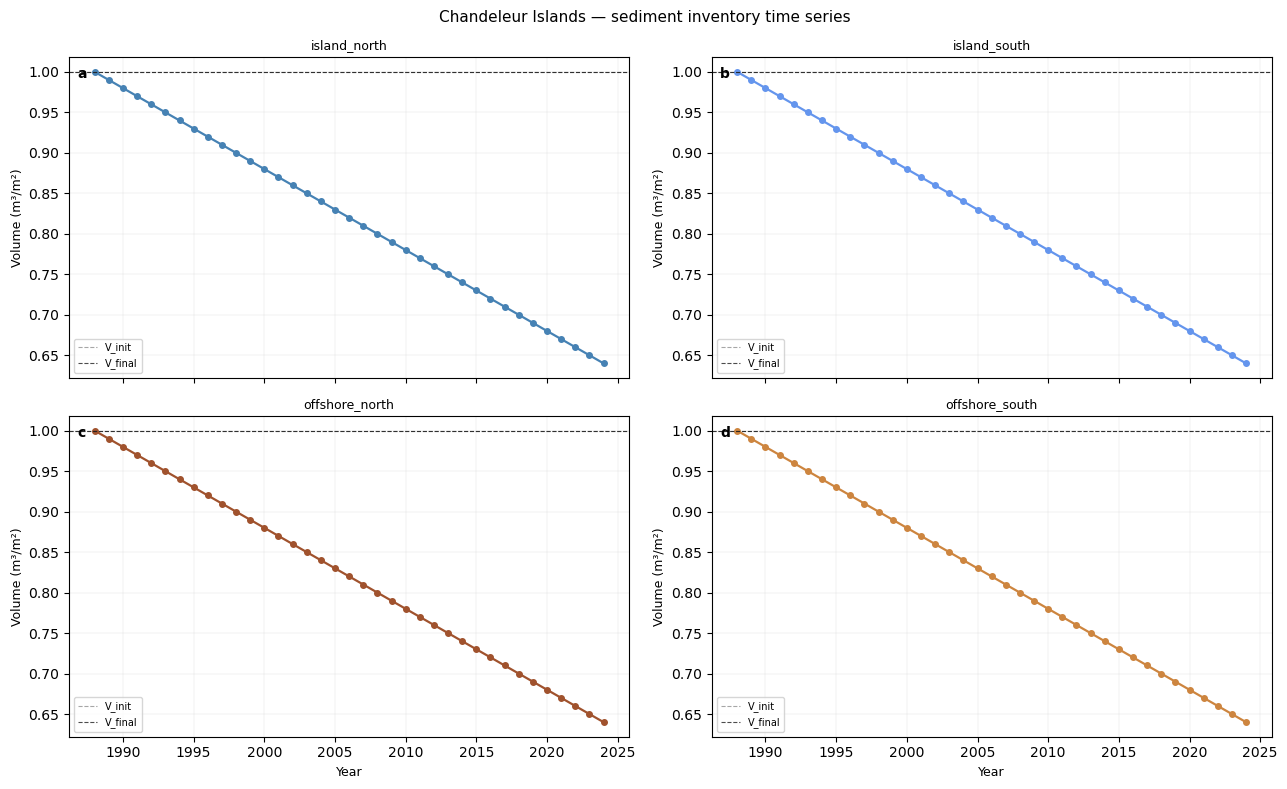

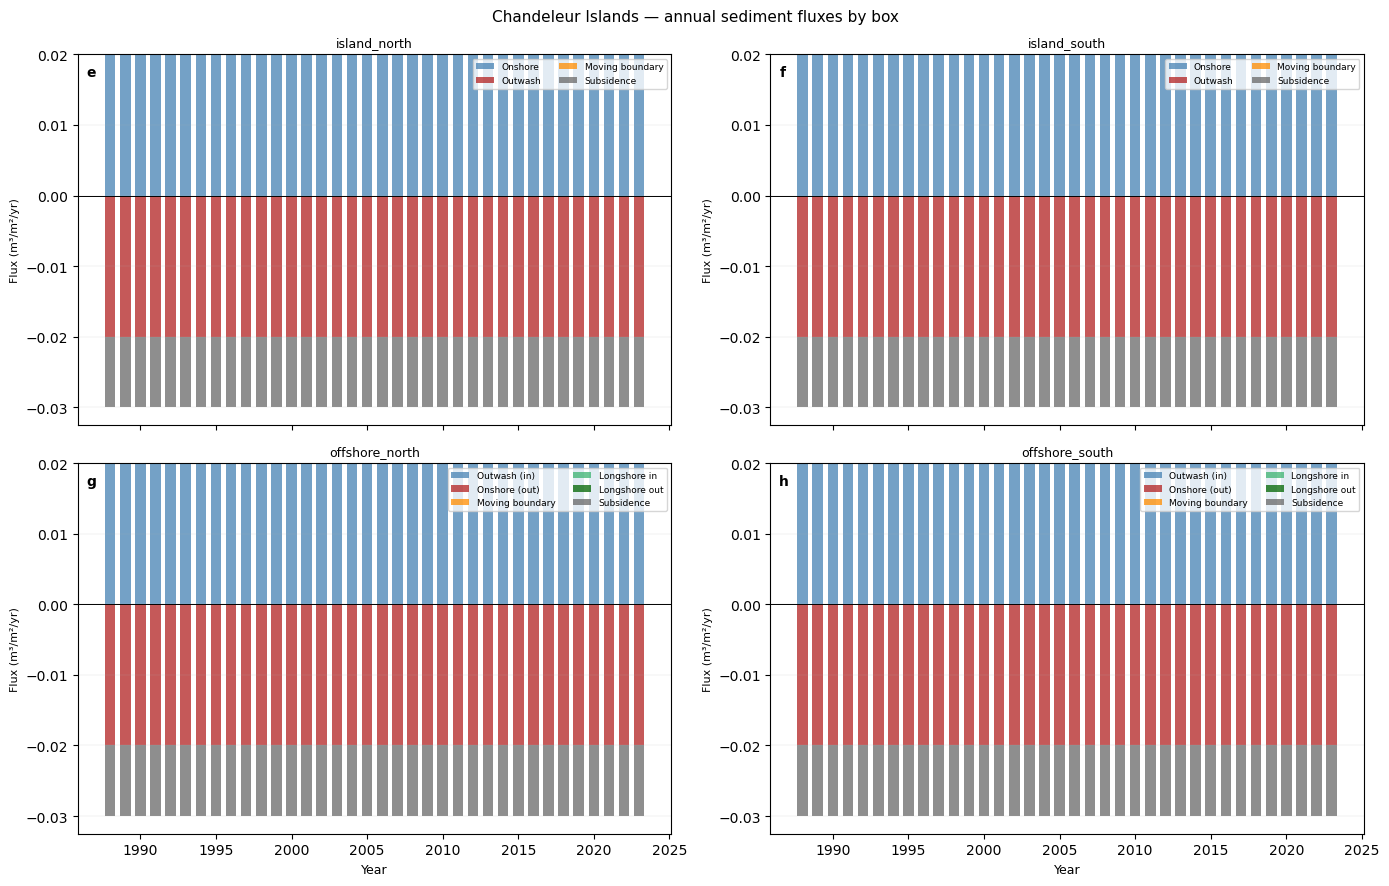

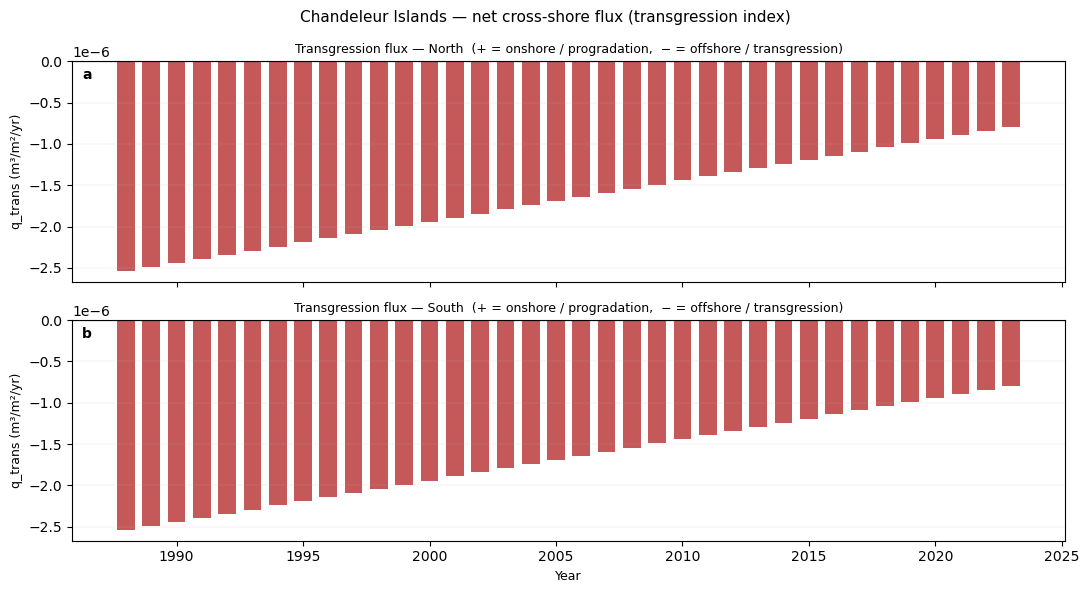

In [7]:
# ==============================================================================
# CELL 7 — Figures
#
# Figure 1 (3-panel): volume time series for all four boxes
# Figure 2 (4-panel): flux breakdown per box (stacked bar, annual)
# Figure 3 (2-panel): transgression flux time series (N and S)
# Panels labelled a, b, c, ... in upper-left corner.
# ==============================================================================

colors = {
    'IN': 'steelblue', 'IS': 'cornflowerblue',
    'ON': 'sienna',    'OS': 'peru',
}
letters = 'abcdefghij'
fl  = flux_ts_sol
yrs = YEARS

# ── Figure 1: Volume time series ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, box, ltr in zip(axes.flat, BOXES, letters):
    ax.plot(yrs, V_ts_sol[box], 'o-', color=colors[box], ms=4, lw=1.6)
    ax.axhline(V_init[box],  color='grey', lw=0.8, ls='--', alpha=0.7, label='V_init')
    ax.axhline(V_final[box], color='k',    lw=0.8, ls='--', alpha=0.7, label='V_final')
    ax.set_ylabel('Volume (m³/m²)', fontsize=9)
    ax.set_title(LABELS[box], fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(lw=0.3, alpha=0.4)
    ax.text(0.015, 0.97, ltr, transform=ax.transAxes,
            fontsize=10, fontweight='bold', va='top')
axes[-1, 0].set_xlabel('Year', fontsize=9)
axes[-1, 1].set_xlabel('Year', fontsize=9)
fig.suptitle('Chandeleur Islands — sediment inventory time series', fontsize=11)
plt.tight_layout()
plt.savefig('Chandeleur_box_volumes.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Stacked annual flux bars per box ────────────────────────────────
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
flux_decomp = {
    'IN': {
        'Onshore':         fl['q_on_N'],
        'Outwash':        -fl['q_out_N'],
        'Moving boundary': fl['q_mb_isl_N'],
        'Subsidence':     -fl['q_sub'],
    },
    'IS': {
        'Onshore':         fl['q_on_S'],
        'Outwash':        -fl['q_out_S'],
        'Moving boundary': fl['q_mb_isl_S'],
        'Subsidence':     -fl['q_sub'],
    },
    'ON': {
        'Outwash (in)':   fl['q_out_N'],
        'Onshore (out)': -fl['q_on_N'],
        'Moving boundary':fl['q_mb_off_N'],
        'Longshore in':   fl['q_LS'],
        'Longshore out':  -fl['q_out_N_LS'],
        'Subsidence':     -fl['q_sub'],
    },
    'OS': {
        'Outwash (in)':   fl['q_out_S'],
        'Onshore (out)': -fl['q_on_S'],
        'Moving boundary':fl['q_mb_off_S'],
        'Longshore in':   fl['q_in'],
        'Longshore out':  -fl['q_LS'],
        'Subsidence':     -fl['q_sub'],
    },
}
cmap_pos = plt.cm.Blues
cmap_neg = plt.cm.Reds
flux_colors = {
    'Onshore':'steelblue','Outwash':'firebrick','Moving boundary':'darkorange',
    'Subsidence':'dimgrey','Outwash (in)':'steelblue','Onshore (out)':'firebrick',
    'Longshore in':'mediumseagreen','Longshore out':'darkgreen',
}
bar_years = fl.index.values

for ax, box, ltr in zip(axes2.flat, BOXES, letters[4:]):
    bottom_pos = np.zeros(len(bar_years))
    bottom_neg = np.zeros(len(bar_years))
    for fname, fseries in flux_decomp[box].items():
        vals = fseries.values
        col  = flux_colors.get(fname, 'grey')
        pos  = np.where(vals >= 0, vals, 0)
        neg  = np.where(vals <  0, vals, 0)
        ax.bar(bar_years, pos, bottom=bottom_pos, color=col,
               alpha=0.75, width=0.7, label=fname)
        ax.bar(bar_years, neg, bottom=bottom_neg, color=col,
               alpha=0.75, width=0.7)
        bottom_pos = bottom_pos + pos
        bottom_neg = bottom_neg + neg
    ax.axhline(0, color='k', lw=0.7)
    ax.set_title(LABELS[box], fontsize=9)
    ax.set_ylabel('Flux (m³/m²/yr)', fontsize=8)
    ax.legend(fontsize=6.5, ncol=2, loc='upper right')
    ax.grid(axis='y', lw=0.3, alpha=0.4)
    ax.text(0.015, 0.97, ltr, transform=ax.transAxes,
            fontsize=10, fontweight='bold', va='top')

axes2[-1, 0].set_xlabel('Year', fontsize=9)
axes2[-1, 1].set_xlabel('Year', fontsize=9)
fig2.suptitle('Chandeleur Islands — annual sediment fluxes by box', fontsize=11)
plt.tight_layout()
plt.savefig('Chandeleur_box_fluxes.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: Transgression flux ─────────────────────────────────────────────
fig3, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, sfx, lbl, ltr in [
        (ax1, 'N', 'North', 'a'), (ax2, 'S', 'South', 'b')]:
    q_tr = fl[f'q_trans_{sfx}']
    ax.bar(bar_years, q_tr, color=np.where(q_tr>=0,'steelblue','firebrick'),
           width=0.7, alpha=0.75)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_ylabel('q_trans (m³/m²/yr)', fontsize=9)
    ax.set_title(f'Transgression flux — {lbl}  '
                 f'(+ = onshore / progradation,  − = offshore / transgression)',
                 fontsize=9)
    ax.grid(axis='y', lw=0.3, alpha=0.4)
    ax.text(0.01, 0.97, ltr, transform=ax.transAxes,
            fontsize=10, fontweight='bold', va='top')
ax2.set_xlabel('Year', fontsize=9)
fig3.suptitle('Chandeleur Islands — net cross-shore flux (transgression index)',
              fontsize=11)
plt.tight_layout()
plt.savefig('Chandeleur_transgression.png', dpi=150, bbox_inches='tight')
plt.show()